# El metano que respira Groenlandia se cocinó hace 2.000 años

**Paper:** Mid-Holocene retreat of the Greenland Ice Sheet indicated by subglacial methane release
**DOI:** [10.1038/s41561-026-01976-5](https://doi.org/10.1038/s41561-026-01976-5)
*Nature Geoscience · 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-07-metano-subglacial-groenlandia/notebook.ipynb)

## Lo que descubrieron

Entre 2021 y 2023, un equipo recorrió **96 puntos de muestreo en 26 ríos** que salen de bajo el hielo del oeste de Groenlandia. Desde Qaanaaq (77,7°N) hasta Narsarsuaq (61,2°N): **1.840 km** de margen glaciar.

En el agua de fusión que emerge bajo el hielo midieron metano. Lo que encontraron no es solo cuánto — también **de qué edad es el carbono** que lo formó.

Veamos qué dicen los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración
# ══════════════════════════════════════════════════════════════
EQUILIBRIO_ATM_NMOLL = 3       # CH4 en equilibrio con la atmósfera
BIOGENIC_THRESHOLD = -50       # δ13C-PDB: por debajo = origen microbiano
HTM_INICIO_KA = 11             # Holocene Thermal Maximum: 11–5 ka BP
HTM_FIN_KA = 5
COLOR_NW = '#059669'           # verde — norte
COLOR_CW = '#D97706'           # ámbar — centro
COLOR_SW = '#DC2626'           # rojo — sur (mayor magnitud)
COLOR_REF = '#2563EB'          # azul — referencia/umbral
FUENTE = 'Fuente: Saunders et al. (2026), Nature Geoscience | Datos: PANGAEA 993007'

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga
# ══════════════════════════════════════════════════════════════
df_full = pd.read_csv('datos/greenland_metano_completo.csv')
df_ch4 = pd.read_csv('datos/ch4_concentraciones.csv')
df_14c = pd.read_csv('datos/edades_radiocarbono.csv')

print(f'Mediciones totales: {len(df_full)}')
print(f'Ríos únicos:        {df_full["river_clean"].nunique()}')
print(f'Latitud:            {df_full["lat"].min():.2f}°N – {df_full["lat"].max():.2f}°N')
print(f'CH₄ con dato:       {df_ch4["ch4_avg_nmoll"].dropna().shape[0]}')
print(f'Muestras 14C:       {len(df_14c)}')
print(f'δ13C medidos:       {df_ch4["d13c_pdb"].dropna().shape[0]}')

Mediciones totales: 96
Ríos únicos:        26
Latitud:            61.15°N – 77.72°N
CH₄ con dato:       53
Muestras 14C:       7
δ13C medidos:       16


## Casi todos los ríos están saturados

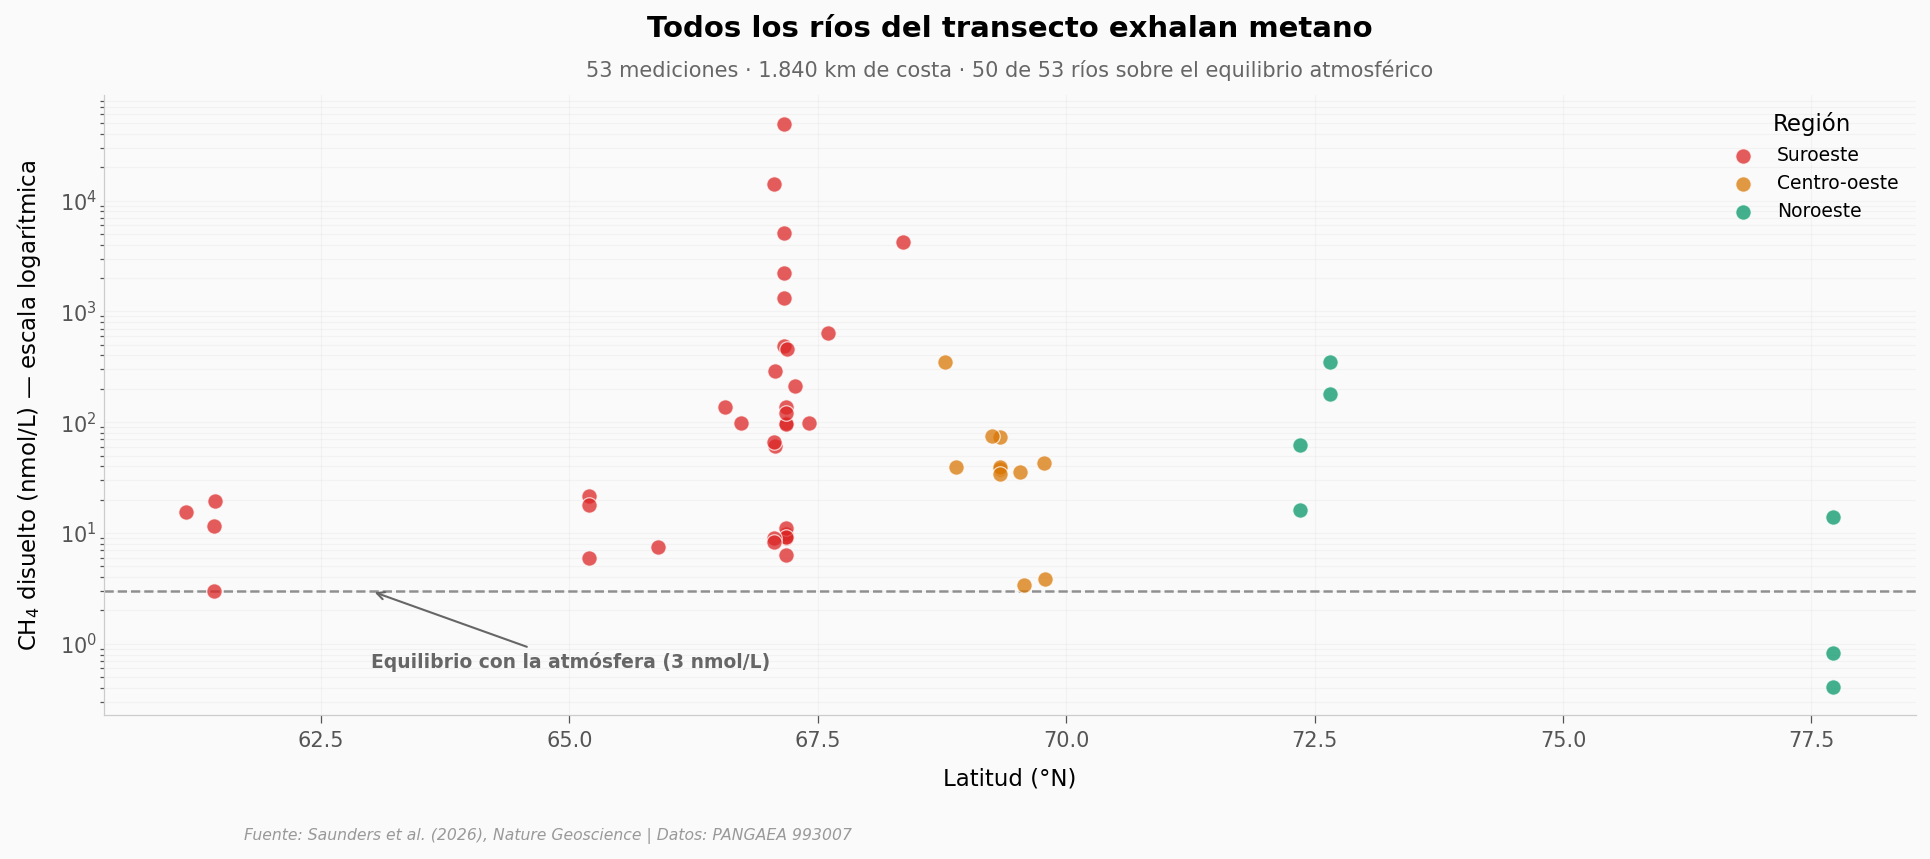

In [2]:
# Gráfica hero: CH4 a lo largo del transecto, escala log
fig, ax = plt.subplots(figsize=(13, 5.5))

ch4 = df_ch4.dropna(subset=['ch4_avg_nmoll', 'lat']).copy()
regiones = [
    ('SW', COLOR_SW, 'Suroeste'),
    ('CW', COLOR_CW, 'Centro-oeste'),
    ('NW', COLOR_NW, 'Noroeste'),
]
for reg, color, label in regiones:
    sub = ch4[ch4['region'] == reg]
    ax.scatter(sub['lat'], sub['ch4_avg_nmoll'], color=color, s=55, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5, label=label)

# Línea de equilibrio atmosférico
ax.axhline(y=EQUILIBRIO_ATM_NMOLL, color='#666666', linewidth=1.2, linestyle='--', alpha=0.7)
ax.annotate('Equilibrio con la atmósfera (3 nmol/L)',
            xy=(63, EQUILIBRIO_ATM_NMOLL), xytext=(63, 0.6),
            fontsize=9, color='#666666', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1))

ax.set_yscale('log')
ax.set_xlabel('Latitud (°N)', fontsize=11)
ax.set_ylabel('CH$_4$ disuelto (nmol/L) — escala logarítmica', fontsize=11)
ax.set_title('Todos los ríos del transecto exhalan metano',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '53 mediciones · 1.840 km de costa · 50 de 53 ríos sobre el equilibrio atmosférico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, title='Región')
ax.grid(True, alpha=0.3, which='both')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_ch4_vs_latitud.png', dpi=200, bbox_inches='tight')
plt.show()

La línea gris discontinua marca el **equilibrio con la atmósfera** (3 nmol/L): el nivel que tendría un río si el metano solo viniera del aire.

**50 de 53 mediciones quedan por encima de esa línea — el 94%.** Los 3 que no la cruzan son ríos del noroeste con caudales bajos.

El suroeste domina la magnitud: su mediana es **95 nmol/L** (vs 16 nmol/L en el noroeste y 39 nmol/L en el centro-oeste). Y el máximo del transecto entero —**49.613 nmol/L**— sale de un río suroccidental: unas **16.500 veces** el equilibrio atmosférico.

## ¿De qué edad es ese carbono?

El metano que sale ahora no se formó ahora. Se formó cuando un microbio descompuso materia orgánica enterrada hace tiempo. El equipo dató el carbono de **7 muestras** por radiocarbono.

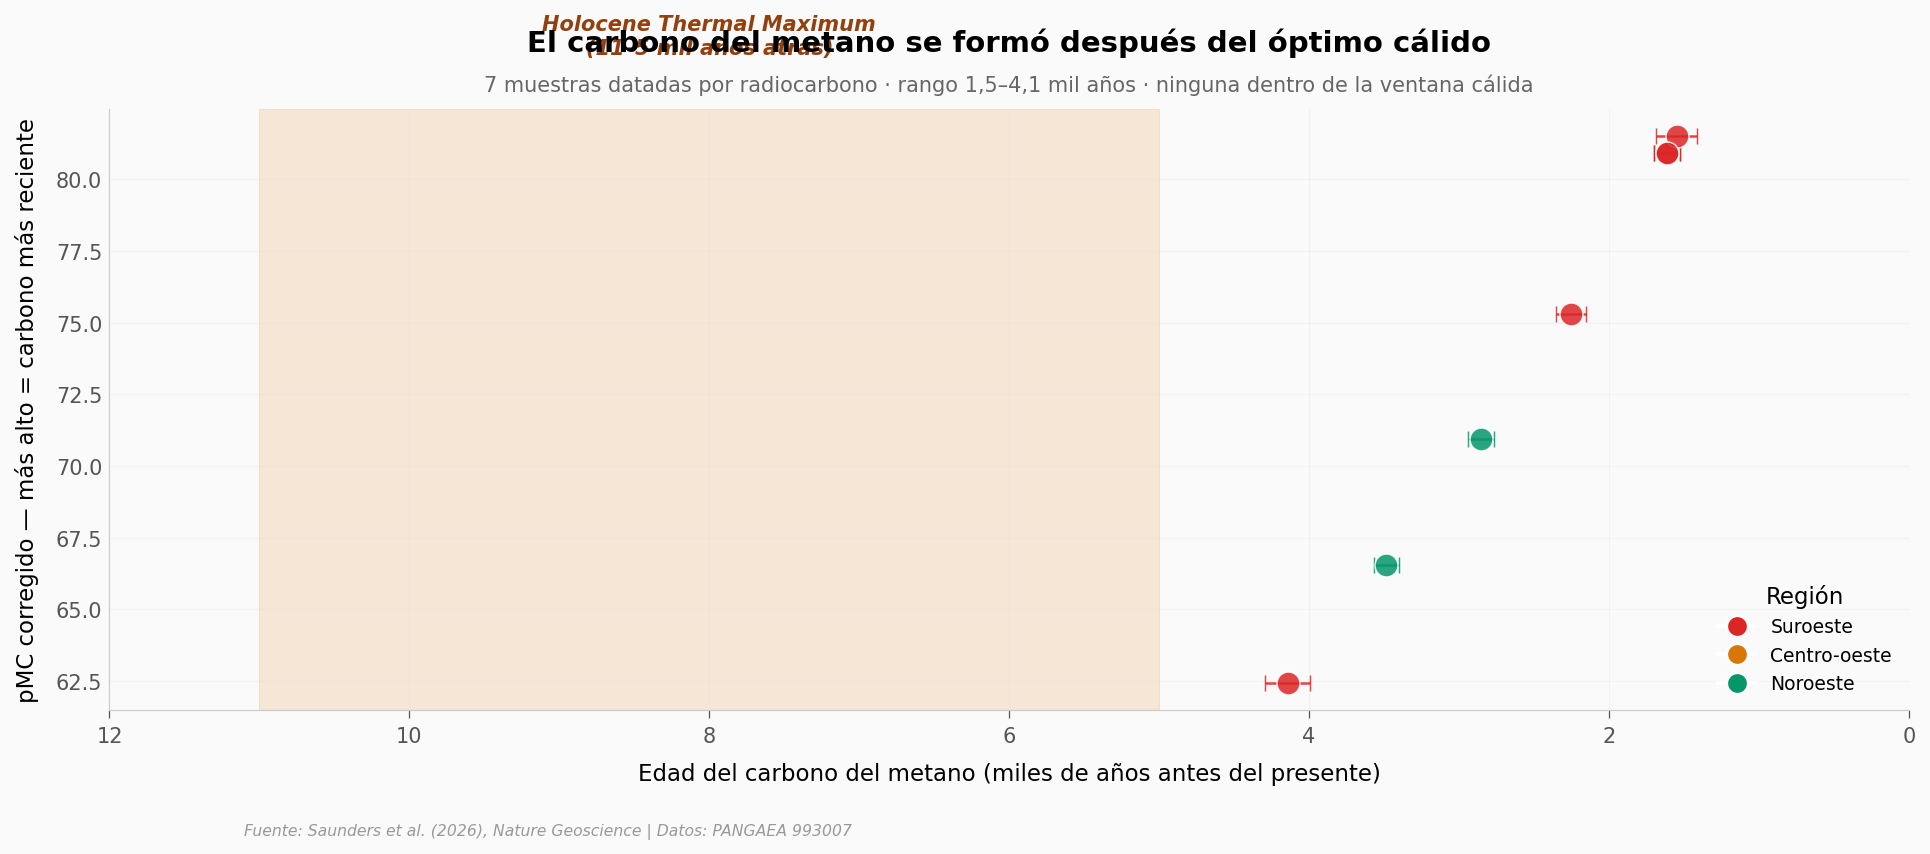

In [3]:
# Edades del carbono del metano: ¿caen en el Holocene Thermal Maximum?
fig, ax = plt.subplots(figsize=(13, 5.5))

ages = df_14c.copy()
# Mid-age con barras horizontales mostrando el rango de incertidumbre
for _, row in ages.iterrows():
    color = COLOR_NW if row['region'] == 'NW' else COLOR_CW if row['region'] == 'CW' else COLOR_SW
    ax.errorbar(row['age_corr_mid_kabp'], row['pmc_corr'],
                xerr=[[row['age_corr_mid_kabp'] - row['age_corr_min_kabp']],
                      [row['age_corr_max_kabp'] - row['age_corr_mid_kabp']]],
                fmt='o', color=color, markersize=11, alpha=0.85,
                markeredgecolor='white', markeredgewidth=0.7,
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=5)

# Sombra del Holocene Thermal Maximum
ax.axvspan(HTM_FIN_KA, HTM_INICIO_KA, alpha=0.15, color='#D97706', zorder=1)
ax.text((HTM_FIN_KA + HTM_INICIO_KA) / 2, 85,
        'Holocene Thermal Maximum\n(11–5 mil años atrás)',
        ha='center', va='center', fontsize=10, color='#92400E',
        fontweight='bold', style='italic')

ax.set_xlabel('Edad del carbono del metano (miles de años antes del presente)', fontsize=11)
ax.set_ylabel('pMC corregido — más alto = carbono más reciente', fontsize=11)
ax.set_title('El carbono del metano se formó después del óptimo cálido',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '7 muestras datadas por radiocarbono · rango 1,5–4,1 mil años · ninguna dentro de la ventana cálida',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 12)
ax.invert_xaxis()  # más antiguo a la izquierda → consistente con flecha temporal
ax.grid(True, alpha=0.3)

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SW,
           markersize=10, label='Suroeste'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_CW,
           markersize=10, label='Centro-oeste'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_NW,
           markersize=10, label='Noroeste'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          framealpha=0.9, title='Región')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_edades_radiocarbono.png', dpi=200, bbox_inches='tight')
plt.show()

**Las 7 muestras caen entre 1,5 y 4,1 mil años atrás.** Ninguna entra en la ventana cálida del Holoceno (11–5 mil años atrás, zona ámbar).

Esto es lo raro: la zona ámbar es cuando Groenlandia se contrajo. Si la materia orgánica del metano hubiera quedado expuesta durante ese retroceso y luego sido sepultada por el avance posterior, esperaríamos edades dentro o anteriores a esa ventana. Los datos muestran lo contrario — el carbono es **post-óptimo cálido**.

La lectura del equipo: después del óptimo cálido, la materia orgánica se siguió acumulando hasta que el hielo volvió a avanzar y la enterró. Los datos son consistentes con una Groenlandia más pequeña que la actual durante el Holoceno medio, pero la datación por sí sola no lo prueba — es una pieza del rompecabezas.

## ¿Cómo se hizo el metano?

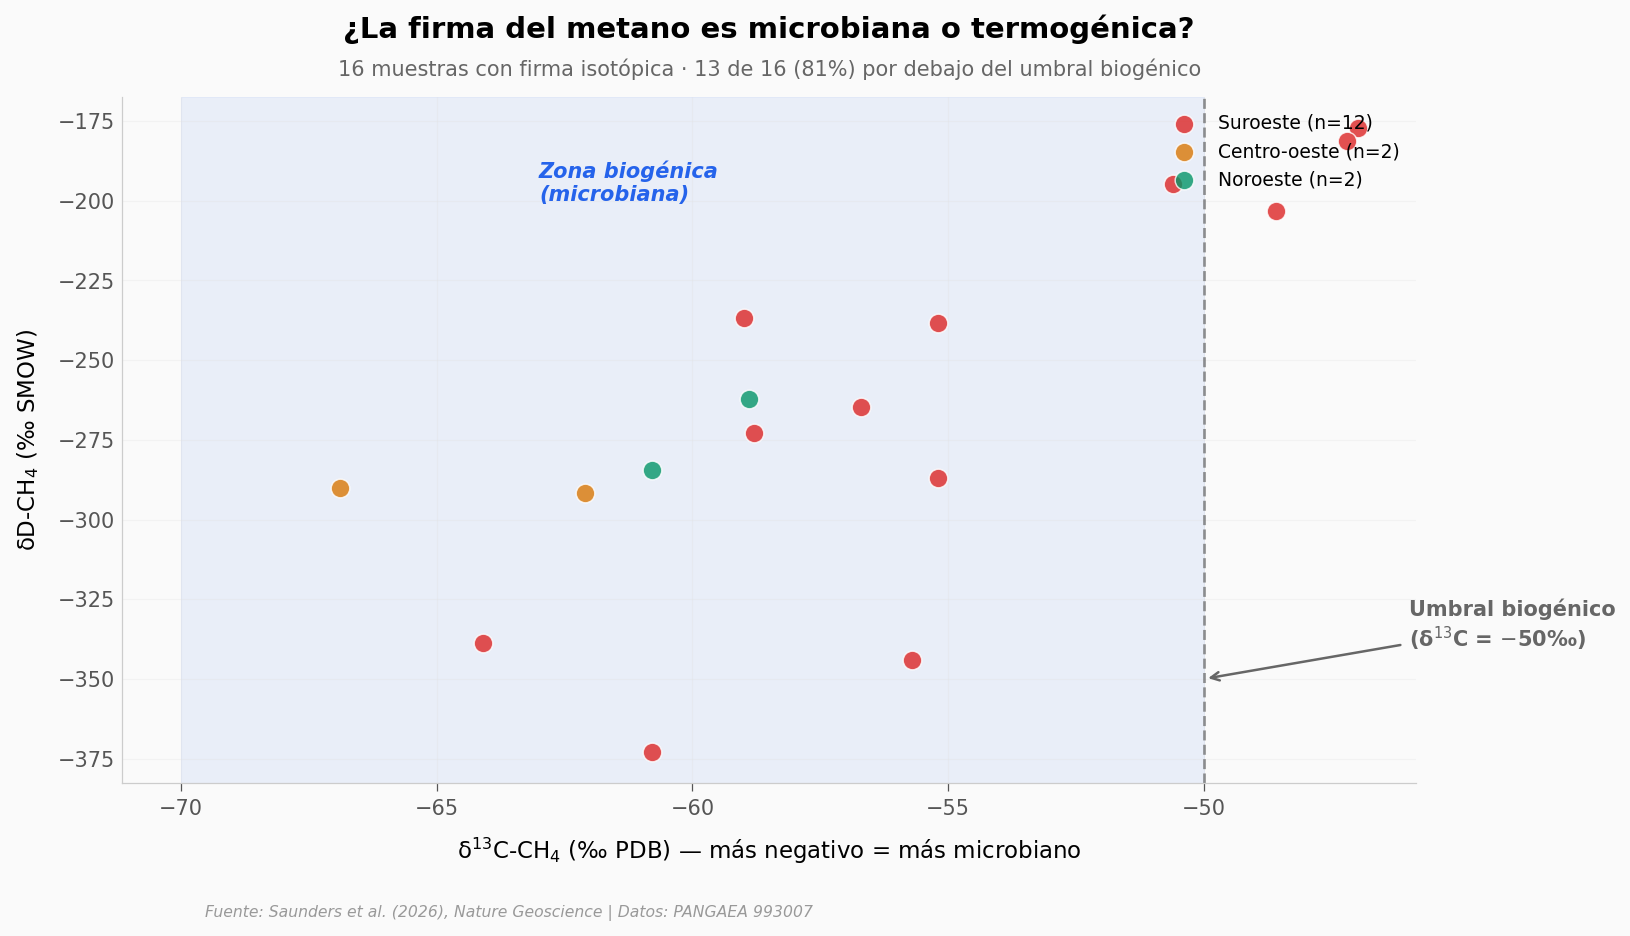

In [4]:
# Firma isotópica: δ13C vs δD (plot de Whiticar)
fig, ax = plt.subplots(figsize=(11, 6))

iso = df_ch4.dropna(subset=['d13c_pdb', 'dd_smow'])
for reg, color, label in [('SW', COLOR_SW, 'Suroeste'),
                           ('CW', COLOR_CW, 'Centro-oeste'),
                           ('NW', COLOR_NW, 'Noroeste')]:
    sub = iso[iso['region'] == reg]
    ax.scatter(sub['d13c_pdb'], sub['dd_smow'], color=color, s=80,
               alpha=0.8, edgecolors='white', linewidths=0.7, zorder=5,
               label=f'{label} (n={len(sub)})')

# Umbral biogénico
ax.axvline(x=BIOGENIC_THRESHOLD, color='#666666', linewidth=1.3,
           linestyle='--', alpha=0.7)
ax.annotate('Umbral biogénico\n(δ$^{13}$C = $-$50‰)',
            xy=(BIOGENIC_THRESHOLD, -350), xytext=(-46, -340),
            fontsize=10, color='#666666', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2))

# Sombra de zona biogénica
ax.axvspan(-70, BIOGENIC_THRESHOLD, alpha=0.08, color=COLOR_REF, zorder=1)
ax.text(-63, -200, 'Zona biogénica\n(microbiana)',
        fontsize=10, color=COLOR_REF, fontweight='bold', style='italic')

ax.set_xlabel('δ$^{13}$C-CH$_4$ (‰ PDB) — más negativo = más microbiano', fontsize=11)
ax.set_ylabel('δD-CH$_4$ (‰ SMOW)', fontsize=11)
ax.set_title('¿La firma del metano es microbiana o termogénica?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '16 muestras con firma isotópica · 13 de 16 (81%) por debajo del umbral biogénico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_isotopos.png', dpi=200, bbox_inches='tight')
plt.show()

**Mediana de δ$^{13}$C: $-$57,8‰.** Bien dentro de la zona biogénica. **13 de 16 muestras (el 81%)** por debajo del umbral $-$50‰.

Traducido: el metano lo hicieron microbios bajo el hielo, descomponiendo carbono orgánico atrapado durante miles de años. No es metano fósil de yacimientos profundos — es biogénico, moderno en su producción pero antiguo en su materia prima.

## ¿Qué tan supersaturado es esto?

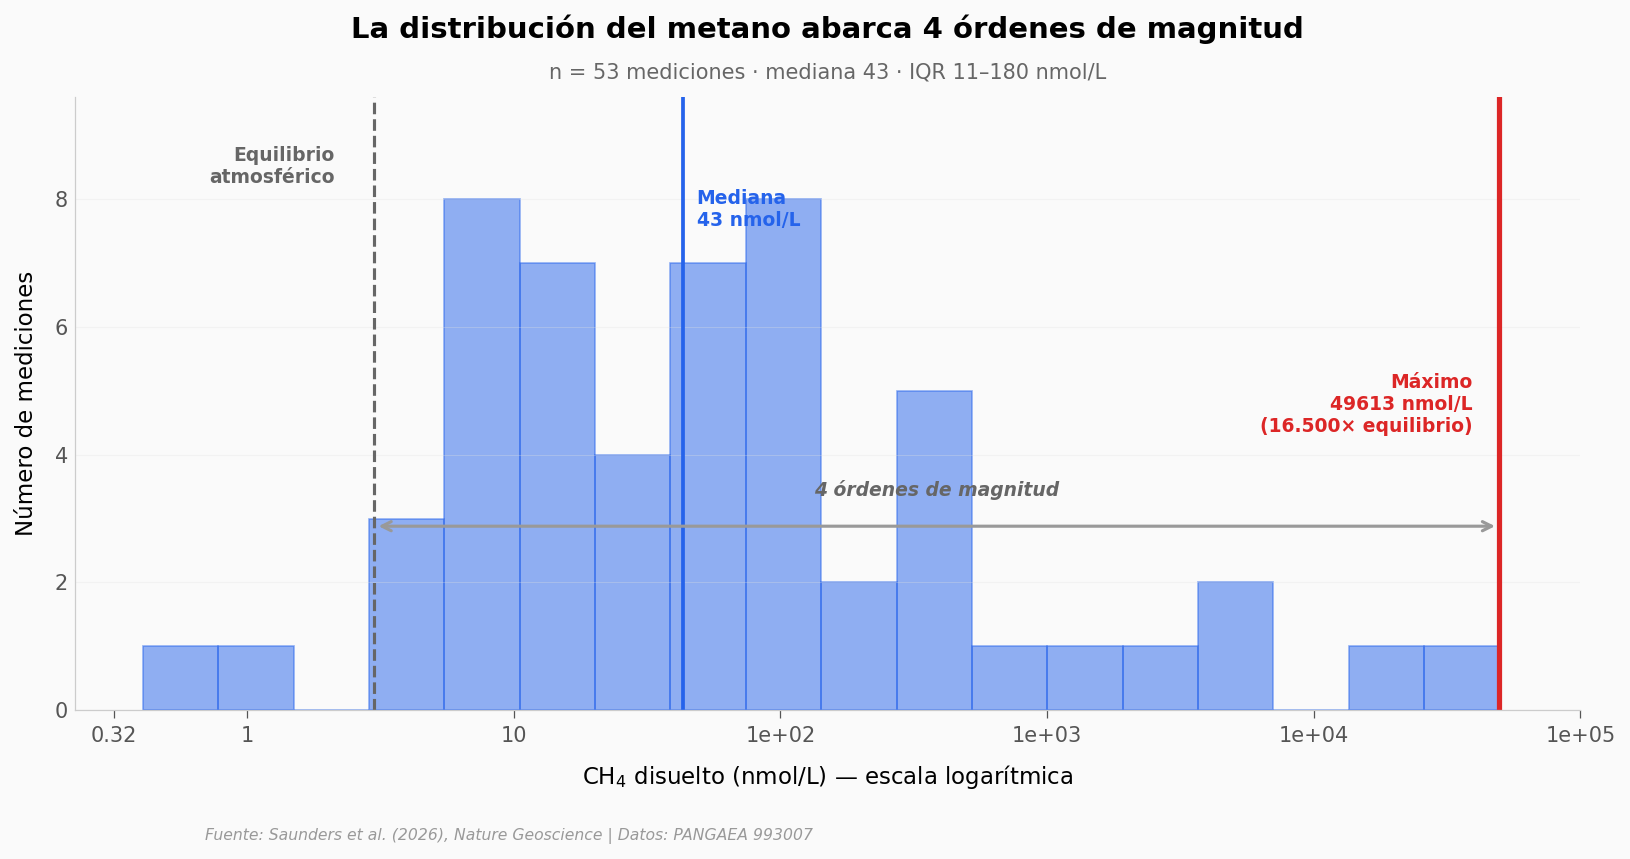

In [5]:
# Distribución del CH4 con escala log + línea del equilibrio atmosférico
fig, ax = plt.subplots(figsize=(11, 5.5))

ch4_vals = df_ch4['ch4_avg_nmoll'].dropna()
log_ch4 = np.log10(ch4_vals)

n, bins, patches = ax.hist(log_ch4, bins=18, color=COLOR_REF, alpha=0.5,
                            edgecolor=COLOR_REF, linewidth=0.8)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Línea de equilibrio atmosférico (log10(3) ≈ 0.477)
log_atm = np.log10(EQUILIBRIO_ATM_NMOLL)
ax.axvline(x=log_atm, color='#666666', linewidth=1.5, linestyle='--')
ax.text(log_atm - 0.15, y_max * 0.92, 'Equilibrio\natmosférico',
        fontsize=9, color='#666666', fontweight='bold',
        ha='right', va='top')

# Mediana
log_median = np.log10(ch4_vals.median())
ax.axvline(x=log_median, color=COLOR_REF, linewidth=1.8)
ax.text(log_median + 0.05, y_max * 0.85, f'Mediana\n{ch4_vals.median():.0f} nmol/L',
        fontsize=9, color=COLOR_REF, fontweight='bold', va='top')

# Máximo (anomalía)
log_max = np.log10(ch4_vals.max())
ax.axvline(x=log_max, color=COLOR_SW, linewidth=2.5)
ax.text(log_max - 0.1, y_max * 0.55,
        f'Máximo\n{ch4_vals.max():.0f} nmol/L\n(16.500× equilibrio)',
        fontsize=9, color=COLOR_SW, fontweight='bold', ha='right', va='top')

# Flecha del rango
ax.annotate('', xy=(log_max, y_max * 0.30), xytext=(log_atm, y_max * 0.30),
            arrowprops=dict(arrowstyle='<->', color='#999999', lw=1.5))
ax.text((log_atm + log_max) / 2, y_max * 0.35,
        '4 órdenes de magnitud',
        fontsize=9, color='#666666', fontweight='bold', ha='center', style='italic')

# Etiquetas de eje X con valores reales
ticks = [-0.5, 0, 1, 2, 3, 4, 5]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{10**t:.2g}' for t in ticks])

ax.set_xlabel('CH$_4$ disuelto (nmol/L) — escala logarítmica', fontsize=11)
ax.set_ylabel('Número de mediciones', fontsize=11)
ax.set_title('La distribución del metano abarca 4 órdenes de magnitud',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'n = {len(ch4_vals)} mediciones · mediana {ch4_vals.median():.0f} · IQR 11–180 nmol/L',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, alpha=0.3, axis='y')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_distribucion_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| 26 ríos muestreados en 1.840 km de costa | ✅ | Lat 61,15°N–77,72°N, 96 mediciones totales |
| 94% de los ríos están supersaturados respecto a la atmósfera | ✅ | 50/53 mediciones >3 nmol/L (equilibrio atmosférico) |
| El metano es biogénico (origen microbiano) | ✅ | Mediana δ$^{13}$C = $-$57,8‰; 13/16 (81%) por debajo del umbral $-$50‰ |
| El carbono del metano se formó hace 1,5–4,4 mil años | ✅ | 7 muestras datadas; nuestro rango midpoints 1,55–4,14 ka (concordante con el paper) |
| Ninguna muestra cae dentro del Holocene Thermal Maximum (5–11 ka) | ✅ | 7/7 muestras post-HTM |
| El suroeste exhala más metano que el norte | ✅ | Mediana SW = 95 nmol/L vs NW = 16 nmol/L |
| Flujo lateral de 715 toneladas/año desde Groenlandia occidental | ⚠️ | El paper lo enmarca como proyección de un modelo de degradación (continuum model), no como medición directa. Los datos PANGAEA no contienen este valor |
| El metano podría seguir emitiéndose por unos 200 años más (proyección del modelo) | ⚠️ | También proyección del mismo modelo; no es una observación |

> **Limitaciones honestas:**
> - **Esto es observacional, no experimental.** Los datos muestran patrones espaciales e isotópicos, pero no prueban causa-efecto. Que las edades coincidan con el Holoceno tardío es **consistente con** un retroceso glaciar más antiguo — no lo prueba.
> - **Tamaños de muestra pequeños** para isótopos (n=16) y radiocarbono (n=7). Las firmas regionales requieren más muestras para distinguir patrones finos.
> - **El máximo de 49.613 nmol/L es un outlier extremo** de un único río suroccidental; la mediana (43 nmol/L) refleja mejor la magnitud típica.
> - **Las cifras de "715 toneladas/año" y "200 años de emisión futura"** vienen de un modelo MATLAB depositado en Zenodo, no del dataset PANGAEA. Tratarlas como proyecciones de modelo, no como medidas.

## Ahora tú

Tres preguntas que los datos pueden responder. Cambia el código y mira qué pasa.

1. **¿Cuán dispersa es la magnitud en el suroeste?** Filtra `df_ch4[df_ch4['region']=='SW']`, calcula media, mediana, percentil 90 y máximo. Comparar con NW.

2. **¿Hay correlación entre conductividad y CH$_4$?** Usa `stats.spearmanr` sobre las filas con ambas variables. ¿Qué tan fuerte es el patrón? Recordar que **ρ$^2$ no es "varianza explicada"** — es concordancia de rangos.

3. **¿Y si todas las muestras de $^{14}$C fueran solo del SW, donde está la magnitud?** Filtra `df_14c[df_14c['region']=='SW']` y mira el rango de edades. ¿Cambia la conclusión sobre el Holoceno?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Estadísticos del suroeste vs del noroeste

for reg, label in [('SW', 'Suroeste'), ('CW', 'Centro-oeste'), ('NW', 'Noroeste')]:
    sub = df_ch4[df_ch4['region'] == reg]['ch4_avg_nmoll'].dropna()
    if len(sub) == 0:
        continue
    print(f'{label} (n={len(sub)})')
    print(f'  mediana:    {sub.median():>10.1f} nmol/L')
    print(f'  IQR:        {sub.quantile(0.25):>5.1f} – {sub.quantile(0.75):.1f} nmol/L')
    print(f'  máximo:     {sub.max():>10.0f} nmol/L')
    print(f'  >equilibrio: {(sub > EQUILIBRIO_ATM_NMOLL).sum()}/{len(sub)} mediciones')
    print()

# Bonus: correlación de Spearman entre conductividad y CH4 (la conductividad
# refleja el tiempo de contacto del agua con el sustrato bajo el hielo)
pair = df_ch4.dropna(subset=['cond_mscm', 'ch4_avg_nmoll'])
if len(pair) >= 10:
    rho, pval = stats.spearmanr(pair['cond_mscm'], pair['ch4_avg_nmoll'])
    print(f'Spearman conductividad vs CH4: ρ = {rho:.2f} (n={len(pair)}, p = {pval:.3f})')
    print('Nota: ρ es correlación de rangos, no varianza explicada.')

Suroeste (n=35)
  mediana:          95.4 nmol/L
  IQR:         10.4 – 375.7 nmol/L
  máximo:          49613 nmol/L
  >equilibrio: 34/35 mediciones

Centro-oeste (n=11)
  mediana:          39.4 nmol/L
  IQR:         35.0 – 58.3 nmol/L
  máximo:            347 nmol/L
  >equilibrio: 11/11 mediciones

Noroeste (n=7)
  mediana:          16.1 nmol/L
  IQR:          7.4 – 121.3 nmol/L
  máximo:            351 nmol/L
  >equilibrio: 5/7 mediciones



---

## Fuentes

**Paper**: [Mid-Holocene retreat of the Greenland Ice Sheet indicated by subglacial methane release](https://doi.org/10.1038/s41561-026-01976-5)  
*Nature Geoscience, 2026-05-05*

**Datos**: [Dissolved Methane release from the western margin of the Greenland Ice Sheet (2021 - 2023)](https://doi.org/10.1594/PANGAEA.993007)  
*PANGAEA · CC-BY 4.0*

*20 afirmaciones del notebook verificadas contra estas fuentes*

## Reproducir

- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Datos:** `papers/2026-05-07-metano-subglacial-groenlandia/datos/`
- **Licencia datos:** CC-BY 4.0 (PANGAEA)
- **Video:** [Pendiente]

*Generado por El Lab — extensión verificable de [Ciencia a Mordiscos](https://www.youtube.com/@ciencia-a-mordiscos).*